In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import fcluster, linkage
from scipy.spatial.distance import pdist, squareform

ROOT = Path.cwd().parent if Path.cwd().name == "diagnostics" else Path.cwd()
sys.path.insert(0, str(ROOT))
from data import load_eci_data, load_benchmark_floors, clip_scores_to_floors
from ppc import posterior_predictive_mirt, compute_gof

ON  = ROOT / "results/mirt_signed_humanprior_lineageprior_floors/trace_mirt_k3_signed_humanprior_lineageprior_floors_8x4000.nc"
OFF = ROOT / "results/recovery_study/trace_withSG_refit.nc"

data = load_eci_data(include_all_benchmarks=True)
floors = load_benchmark_floors(data)
clipped = clip_scores_to_floors(data, floors)
BENCH = np.array(list(data.blookup.sort_values("benchmark_idx")["benchmark"]))
SG = list(data.mlookup.sort_values("model_idx")["model"]).index("Skilled Generalist")
# SG-relevant benchmarks (SG has observations on GPQA Diamond and ARC-AGI)
BREAKERS = ["GPQA Diamond", "ARC-AGI", "ARC-AGI-2", "OTIS Mock AIME 2024-2025"]

idata = az.from_netcdf(ON)
# load the analysed groups into memory once: repeated fancy-indexed isel on the
# lazily-opened 4GB HDF5 file trips h5py's hyperslab selector
idata.posterior.load()
idata.sample_stats.load()
NCH, NDR = idata.posterior.sizes["chain"], idata.posterior.sizes["draw"]
print(f"K=3 3PL trace (final, 8x4000): {NCH} chains x {NDR} draws")

K=3 3PL trace (final, 8x4000): 8 chains x 4000 draws


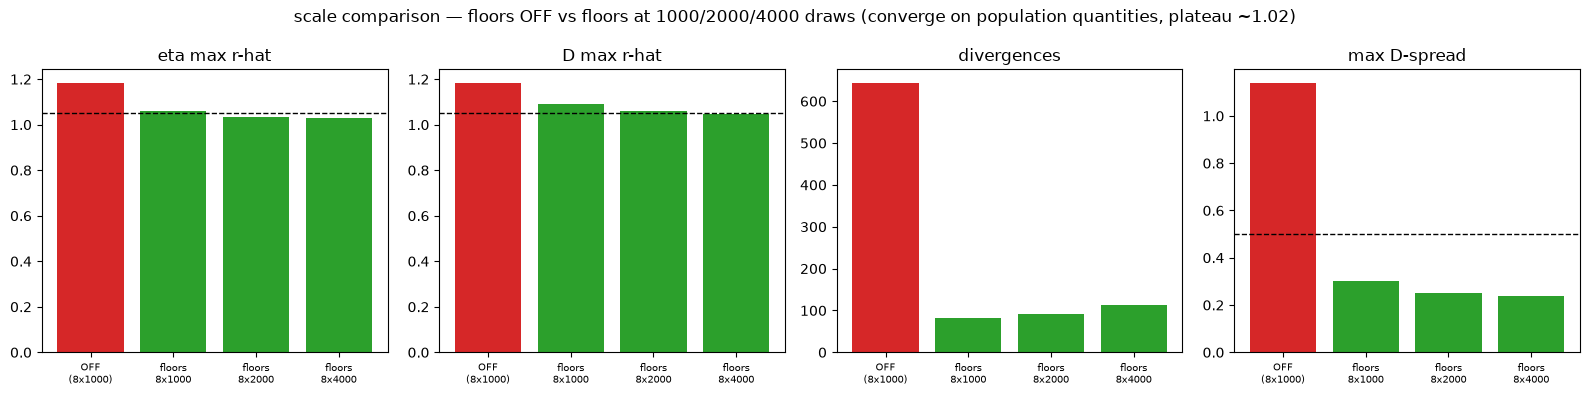

In [2]:
# recorded metrics across the campaign (this notebook's trace = the 8x4000 col)
SCALE = {
    "OFF\n(8x1000)": {"eta_rhat": 1.184, "D_rhat": 1.184, "div": 644, "logp_spread": 65.8, "D_spread": 1.14},
    "floors\n8x1000": {"eta_rhat": 1.060, "D_rhat": 1.092, "div": 82, "logp_spread": 38.2, "D_spread": 0.30},
    "floors\n8x2000": {"eta_rhat": 1.036, "D_rhat": 1.060, "div": 92, "logp_spread": 12.9, "D_spread": 0.25},
    "floors\n8x4000": {"eta_rhat": 1.029, "D_rhat": 1.049, "div": 114, "logp_spread": 14.7, "D_spread": 0.24},
}
cols = list(SCALE)
fig, ax = plt.subplots(1, 4, figsize=(16, 4))
for a, (key, title, ref) in zip(ax, [
        ("eta_rhat", "eta max r-hat", 1.05), ("D_rhat", "D max r-hat", 1.05),
        ("div", "divergences", None), ("D_spread", "max D-spread", 0.5)]):
    vals = [SCALE[c][key] for c in cols]
    bars = a.bar(cols, vals, color=["tab:red"] + ["tab:green"]*3)
    if ref: a.axhline(ref, ls="--", c="k", lw=1)
    a.set(title=title); a.tick_params(axis="x", labelsize=7)
fig.suptitle("scale comparison — floors OFF vs floors at 1000/2000/4000 draws "
             "(converge on population quantities, plateau ~1.02)")
fig.tight_layout(); plt.show()

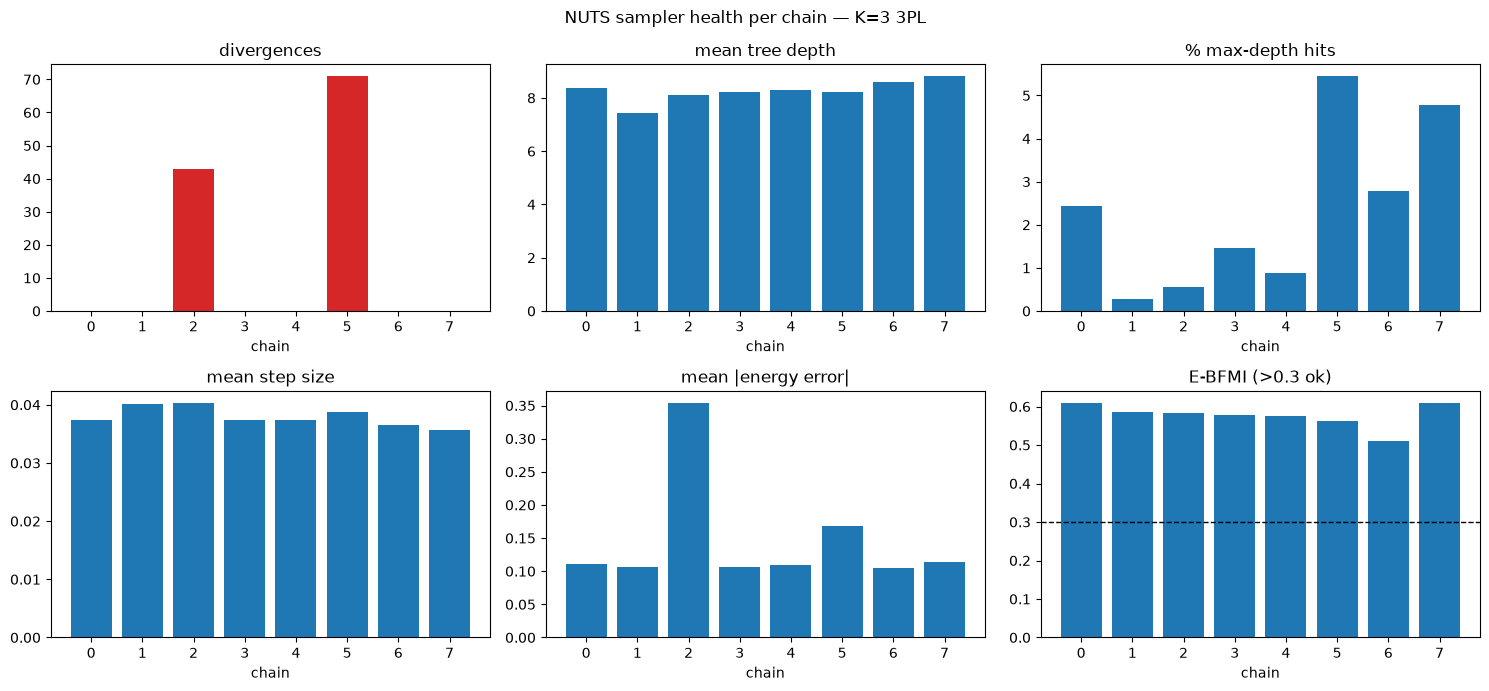

In [3]:
ss = idata.sample_stats
div = ss["diverging"].values.sum(axis=1).astype(int)
depth = ss["depth"].values.mean(axis=1)
maxd = ss["maxdepth_reached"].values.mean(axis=1) * 100
step = ss["step_size"].values.mean(axis=1)
ee = np.abs(ss["energy_error"].values).mean(axis=1)
# E-BFMI per chain
en = ss["energy"].values
bfmi = np.array([np.sum(np.diff(en[c])**2) / np.sum((en[c] - en[c].mean())**2) for c in range(NCH)])

fig, ax = plt.subplots(2, 3, figsize=(15, 7))
for a, (vals, title) in zip(ax.ravel(), [
        (div, "divergences"), (depth, "mean tree depth"),
        (maxd, "% max-depth hits"), (step, "mean step size"),
        (ee, "mean |energy error|"), (bfmi, "E-BFMI (>0.3 ok)")]):
    ax_c = ["tab:red" if title == "divergences" and v > 0 else "tab:blue" for v in vals]
    a.bar(range(NCH), vals, color=ax_c)
    a.set(title=title, xlabel="chain")
    if title.startswith("E-BFMI"):
        a.axhline(0.3, ls="--", c="k", lw=1)
fig.suptitle("NUTS sampler health per chain — K=3 3PL")
fig.tight_layout(); plt.show()

               family  max_rhat  min_bulk_ess  median_bulk_ess  min_tail_ess
     eta (identified)     1.062          74.9          28684.4         203.0
       D (identified)     1.049         107.6          12073.8         268.7
 sigma_b (identified)     1.026         203.7          21763.6         394.3
  tau_CD (identified)     1.004        2586.9           2586.9        3987.4
    A (raw, permuted)       2.4           9.7             12.9          22.0
theta (raw, permuted)       2.5           9.6             15.2          21.8


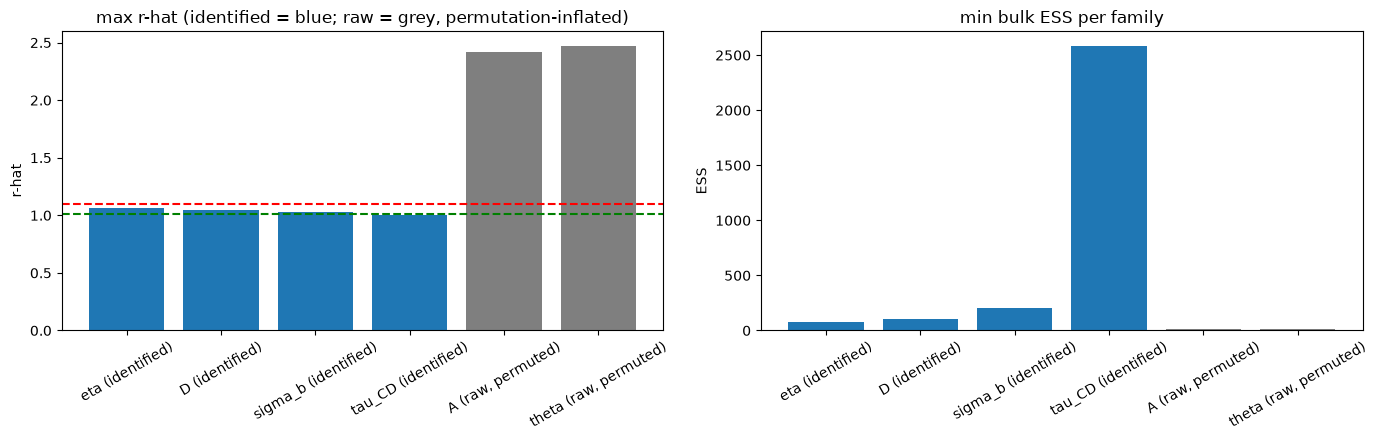

In [4]:
rng = np.random.default_rng(0)
sub = rng.choice(data.n_obs, 300, replace=False)
bi, mi = clipped.bench_idx[sub], clipped.model_idx[sub]
A = idata.posterior["A"]; th = idata.posterior["theta"]; D = idata.posterior["D"]
eta = (A.isel(bench=("obs", bi)) * th.isel(model=("obs", mi))).sum("latent") - D.isel(bench=("obs", bi))
eta = eta.rename("eta").to_dataset()

fams = {"eta (identified)": eta["eta"],
        "D (identified)": D, "sigma_b (identified)": idata.posterior["sigma_b"],
        "tau_CD (identified)": idata.posterior["tau_CD"],
        "A (raw, permuted)": A, "theta (raw, permuted)": th}
rows = []
for name, da in fams.items():
    r = az.rhat(da).to_array().values
    eb = az.ess(da).to_array().values
    et = az.ess(da, method="tail").to_array().values
    rows.append({"family": name, "max_rhat": float(np.nanmax(r)),
                 "min_bulk_ess": float(np.nanmin(eb)), "median_bulk_ess": float(np.nanmedian(eb)),
                 "min_tail_ess": float(np.nanmin(et))})
tbl = pd.DataFrame(rows)
pd.set_option("display.width", 200)
print(tbl.to_string(index=False, float_format=lambda x: f"{x:.1f}" if x > 2 else f"{x:.3f}"))

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].bar(tbl["family"], tbl["max_rhat"], color=["tab:blue"]*4 + ["tab:grey"]*2)
ax[0].axhline(1.01, ls="--", c="g"); ax[0].axhline(1.1, ls="--", c="r")
ax[0].set(title="max r-hat (identified = blue; raw = grey, permutation-inflated)", ylabel="r-hat")
ax[0].tick_params(axis="x", rotation=30)
ax[1].bar(tbl["family"], tbl["min_bulk_ess"], color=["tab:blue"]*4 + ["tab:grey"]*2)
ax[1].set(title="min bulk ESS per family", ylabel="ESS"); ax[1].tick_params(axis="x", rotation=30)
fig.tight_layout(); plt.show()

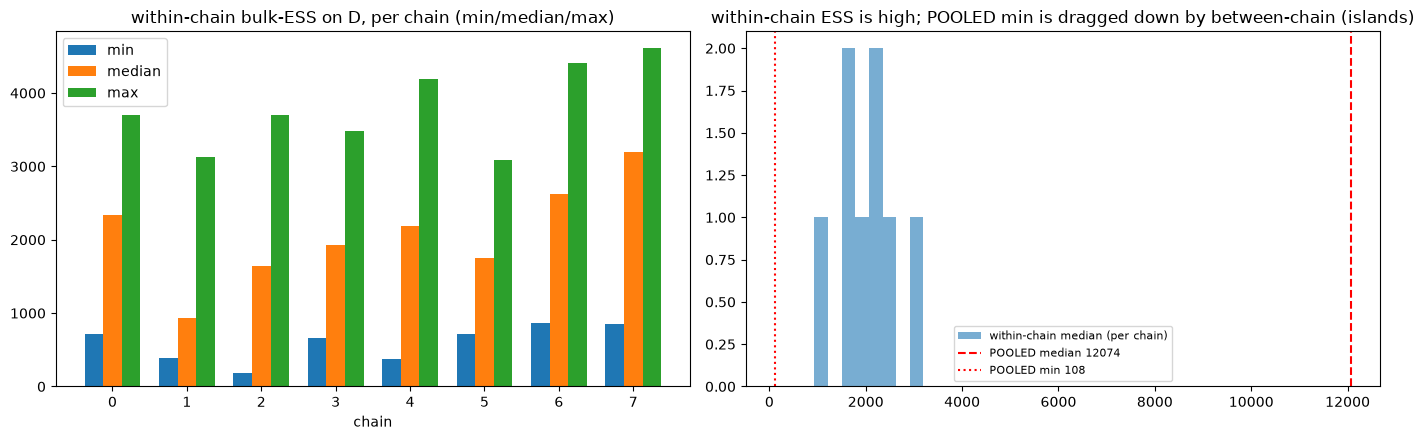

In [5]:
D_arr = idata.posterior["D"]                      # (chain, draw, bench)
rows = []
for c in range(NCH):
    e = az.ess(D_arr.isel(chain=[c])).to_array().values.ravel()   # within-chain only
    rows.append([np.nanmin(e), np.nanmedian(e), np.nanmax(e)])
rows = np.array(rows)
pooled = az.ess(D_arr).to_array().values.ravel()

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
x = np.arange(NCH)
ax[0].bar(x-0.25, rows[:,0], 0.25, label="min")
ax[0].bar(x,      rows[:,1], 0.25, label="median")
ax[0].bar(x+0.25, rows[:,2], 0.25, label="max")
ax[0].set(title="within-chain bulk-ESS on D, per chain (min/median/max)", xlabel="chain")
ax[0].legend()
ax[1].hist(rows[:,1], bins=8, alpha=0.6, label="within-chain median (per chain)")
ax[1].axvline(np.nanmedian(pooled), ls="--", c="r", label=f"POOLED median {np.nanmedian(pooled):.0f}")
ax[1].axvline(np.nanmin(pooled), ls=":", c="r", label=f"POOLED min {np.nanmin(pooled):.0f}")
ax[1].set(title="within-chain ESS is high; POOLED min is dragged down by between-chain (islands)")
ax[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

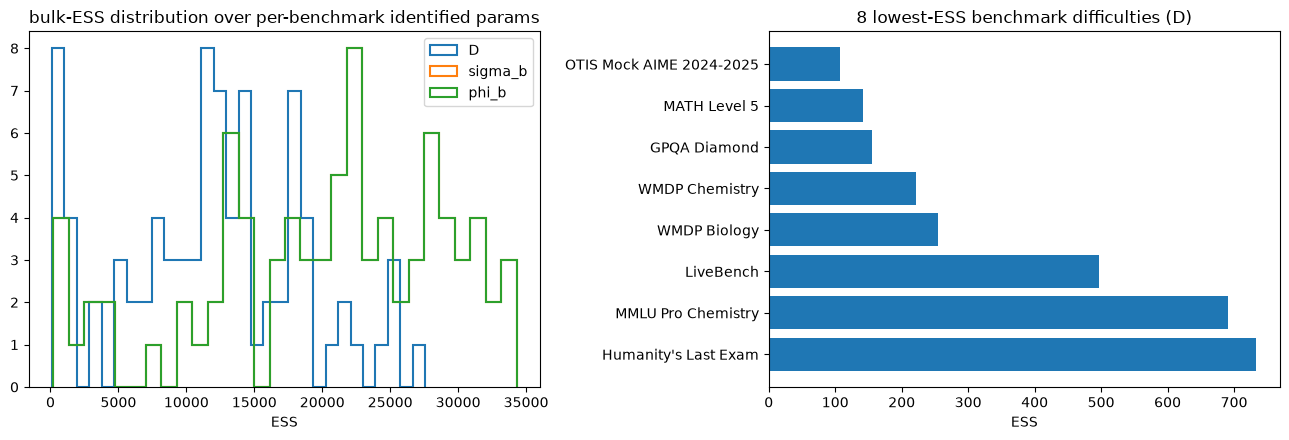

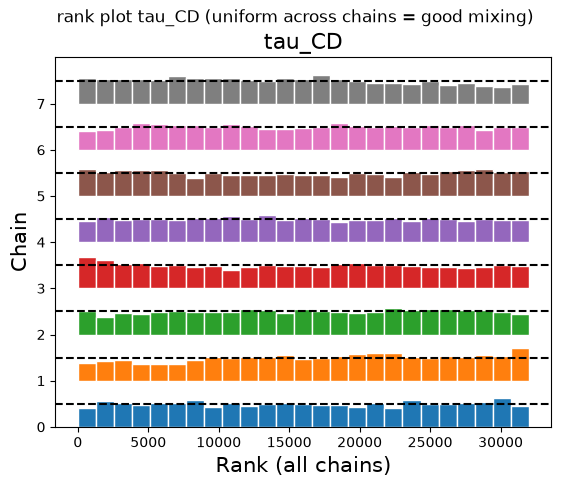

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for name, col in [("D", "tab:blue"), ("sigma_b", "tab:orange"), ("phi_b", "tab:green")]:
    e = az.ess(idata.posterior[name]).to_array().values.ravel()
    ax[0].hist(e, bins=30, histtype="step", lw=1.5, label=name, color=col)
ax[0].set(title="bulk-ESS distribution over per-benchmark identified params", xlabel="ESS")
ax[0].legend()
D_ess = az.ess(idata.posterior["D"]).to_array().values.ravel()
order = np.argsort(D_ess)[:8]
ax[1].barh([BENCH[i][:24] for i in order][::-1], D_ess[order][::-1], color="tab:blue")
ax[1].set(title="8 lowest-ESS benchmark difficulties (D)", xlabel="ESS")
fig.tight_layout(); plt.show()

az.plot_rank(idata, var_names=["tau_CD"])
plt.suptitle("rank plot tau_CD (uniform across chains = good mixing)"); plt.show()

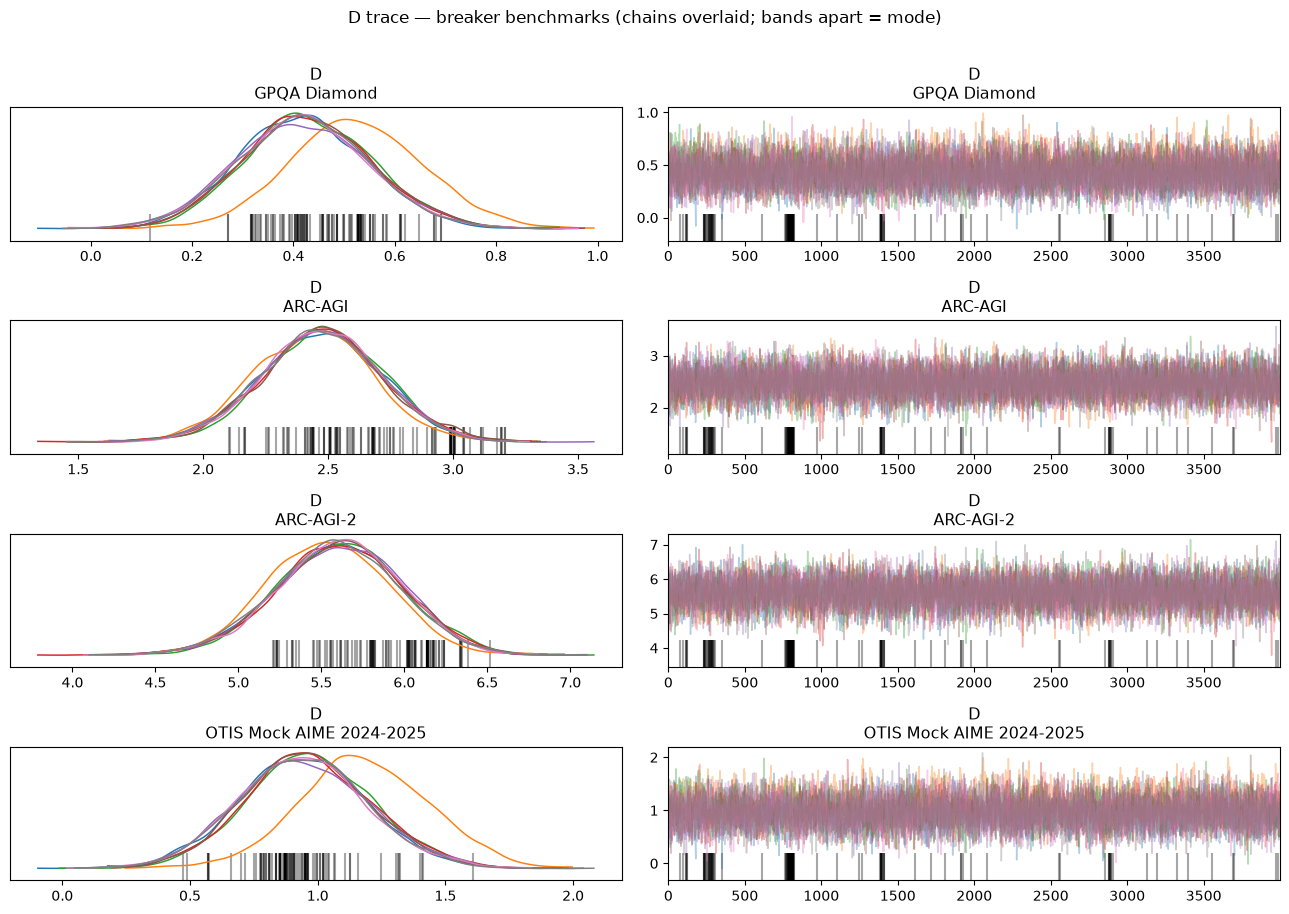

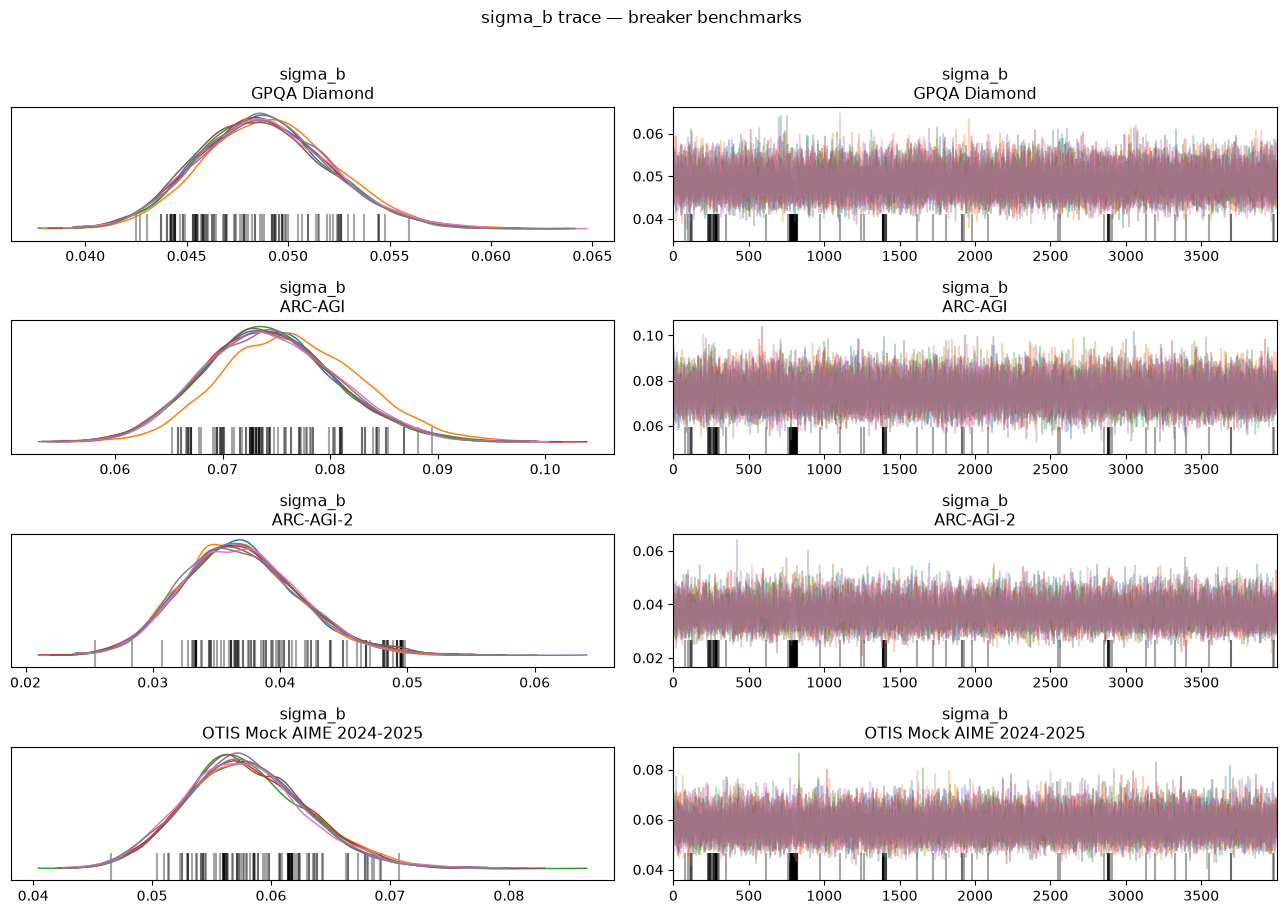

In [7]:
az.plot_trace(idata, var_names=["D"], coords={"bench": BREAKERS}, compact=False,
              figsize=(13, 9))
plt.suptitle("D trace — breaker benchmarks (chains overlaid; bands apart = mode)", y=1.01)
plt.tight_layout(); plt.show()

az.plot_trace(idata, var_names=["sigma_b"], coords={"bench": BREAKERS}, compact=False,
              figsize=(13, 9))
plt.suptitle("sigma_b trace — breaker benchmarks", y=1.01)
plt.tight_layout(); plt.show()

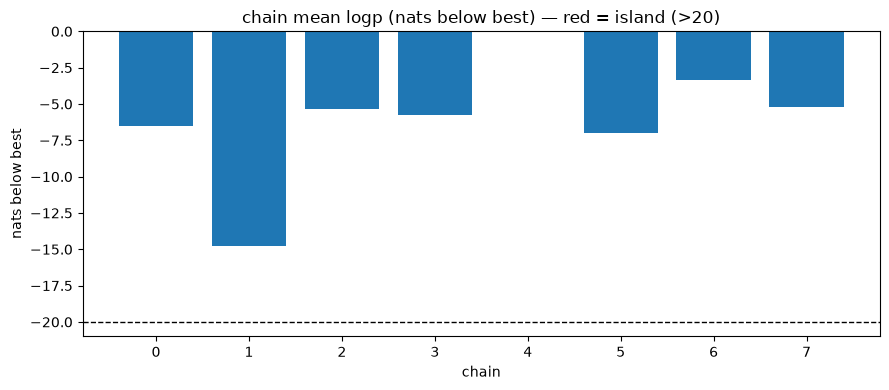

In [8]:
logp = idata.sample_stats["logp"].mean("draw").values
below = logp - logp.max()
maj = logp > logp.max() - 20.0
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(NCH), below, color=["tab:red" if not m else "tab:blue" for m in maj])
ax.axhline(-20, ls="--", c="k", lw=1)
ax.set(title="chain mean logp (nats below best) — red = island (>20)", xlabel="chain",
       ylabel="nats below best")
plt.tight_layout(); plt.show()

chain  perm      sign        min loading corr   verdict
  c0   [0, 1, 2]  [1, 1, 1]   0.775             majority
  c1   [0, 2, 1]  [-1, 1, 1]   0.489             ISLAND
  c2   [1, 0, 2]  [1, 1, 1]   0.761             majority
  c3   [2, 0, 1]  [1, 1, 1]   0.696             majority
  c4   [1, 0, 2]  [1, 1, 1]   0.726             majority
  c5   [0, 1, 2]  [1, 1, 1]   0.757             majority
  c6   [0, 2, 1]  [1, 1, 1]   0.748             majority
  c7   [1, 2, 0]  [1, 1, 1]   0.766             majority


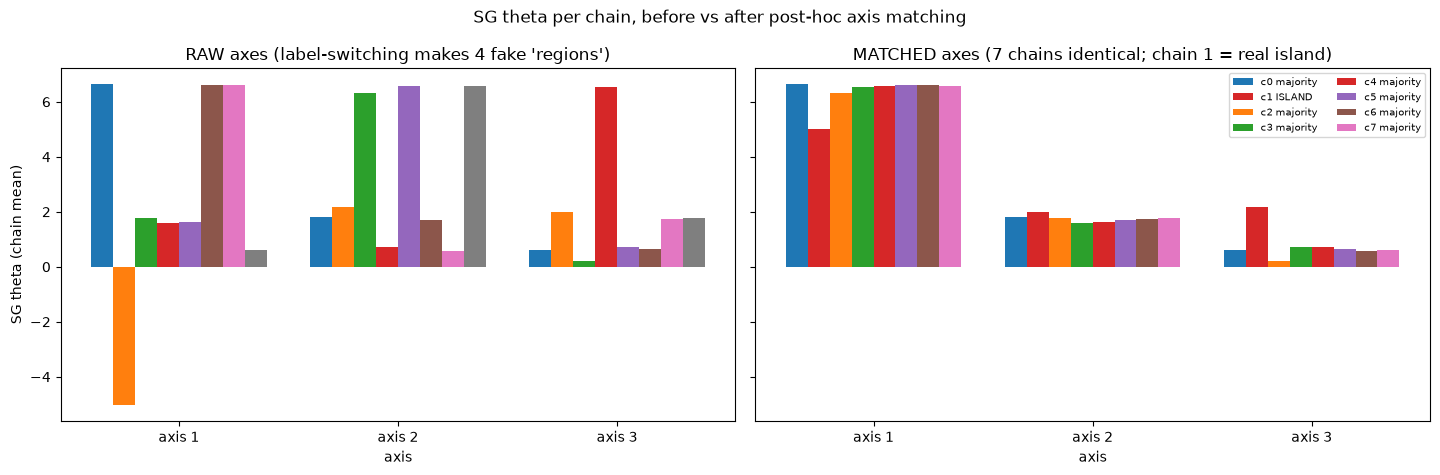

In [9]:
REF = [0, 5, 6]
Aref = idata.posterior["A"].isel(chain=REF).mean(("chain", "draw")).values   # (bench, K)

def match_to_ref(c):
    Ac = idata.posterior["A"].isel(chain=[c]).mean(("chain", "draw")).values
    used, perm, sign = set(), [0]*3, [1.0]*3
    for ja in range(3):
        best = (-1.0, 0, 1.0)
        for jb in range(3):
            if jb in used: continue
            r = np.corrcoef(Aref[:, ja], Ac[:, jb])[0, 1]
            if abs(r) > best[0]: best = (abs(r), jb, np.sign(r))
        perm[ja], sign[ja] = best[1], best[2]; used.add(best[1])
    Ac_m = np.column_stack([sign[j]*Ac[:, perm[j]] for j in range(3)])
    corr = [float(np.corrcoef(Aref[:, j], Ac_m[:, j])[0, 1]) for j in range(3)]
    return perm, sign, corr

MATCH = [match_to_ref(c) for c in range(NCH)]
th_raw = idata.posterior["theta"].values[:, :, SG, :].mean(axis=1)          # (chain, K)
th_m = np.array([[MATCH[c][1][j]*th_raw[c, MATCH[c][0][j]] for j in range(3)]
                 for c in range(NCH)])
# a chain is the SAME solution as the reference iff matched loadings agree on all axes
# axis 3 is weak, so same-solution chains only reach ~0.7 on it; the true
# island (chain 1) sits at ~0.49 — threshold between the two clusters
same = np.array([min(MATCH[c][2]) > 0.6 for c in range(NCH)])
labels = [("majority" if same[c] else "ISLAND") for c in range(NCH)]

print("chain  perm      sign        min loading corr   verdict")
for c in range(NCH):
    p, s, r = MATCH[c]
    print(f"  c{c}   {p}  {[int(x) for x in s]}   {min(r):.3f}             {labels[c]}")

fig, ax = plt.subplots(1, 2, figsize=(14.5, 4.8), sharey=True)
w = 0.1
for c in range(NCH):
    ax[0].bar(np.arange(3) + c*w, th_raw[c], width=w, label=f"c{c}")
    ax[1].bar(np.arange(3) + c*w, th_m[c], width=w,
              color=("tab:red" if not same[c] else None), label=f"c{c} {labels[c]}")
for a, t in zip(ax, ["RAW axes (label-switching makes 4 fake 'regions')",
                     "MATCHED axes (7 chains identical; chain 1 = real island)"]):
    a.set(title=t, xlabel="axis", xticks=np.arange(3) + 3.5*w,
          xticklabels=["axis 1", "axis 2", "axis 3"])
ax[0].set_ylabel("SG theta (chain mean)")
ax[1].legend(ncol=2, fontsize=7)
fig.suptitle("SG theta per chain, before vs after post-hoc axis matching")
fig.tight_layout(); plt.show()

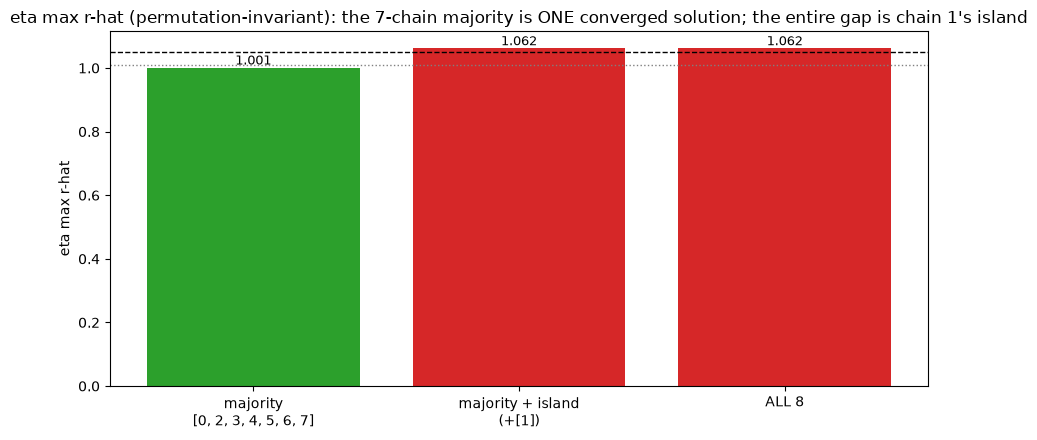

In [10]:
majority = [c for c in range(NCH) if same[c]]
island = [c for c in range(NCH) if not same[c]]

def eta_rhat(chains):
    d = idata.sel(chain=chains)
    e = (d.posterior["A"].isel(bench=("obs", bi)) * d.posterior["theta"].isel(model=("obs", mi))
         ).sum("latent") - d.posterior["D"].isel(bench=("obs", bi))
    return float(np.nanmax(az.rhat(e.rename("eta").to_dataset())["eta"].values))

names = [f"majority\n{majority}", f"majority + island\n(+{island})", "ALL 8"]
vals = [eta_rhat(majority), eta_rhat(majority + island), eta_rhat(list(range(NCH)))]
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(names, vals, color=["tab:green", "tab:red", "tab:red"])
ax.axhline(1.05, ls="--", c="k", lw=1)
ax.axhline(1.01, ls=":", c="grey", lw=1)
for x, v in zip(names, vals):
    ax.annotate(f"{v:.3f}", (x, v), ha="center", va="bottom", fontsize=9)
ax.set(title="eta max r-hat (permutation-invariant): the 7-chain majority is ONE "
       "converged solution; the entire gap is chain 1's island",
       ylabel="eta max r-hat")
plt.tight_layout(); plt.show()

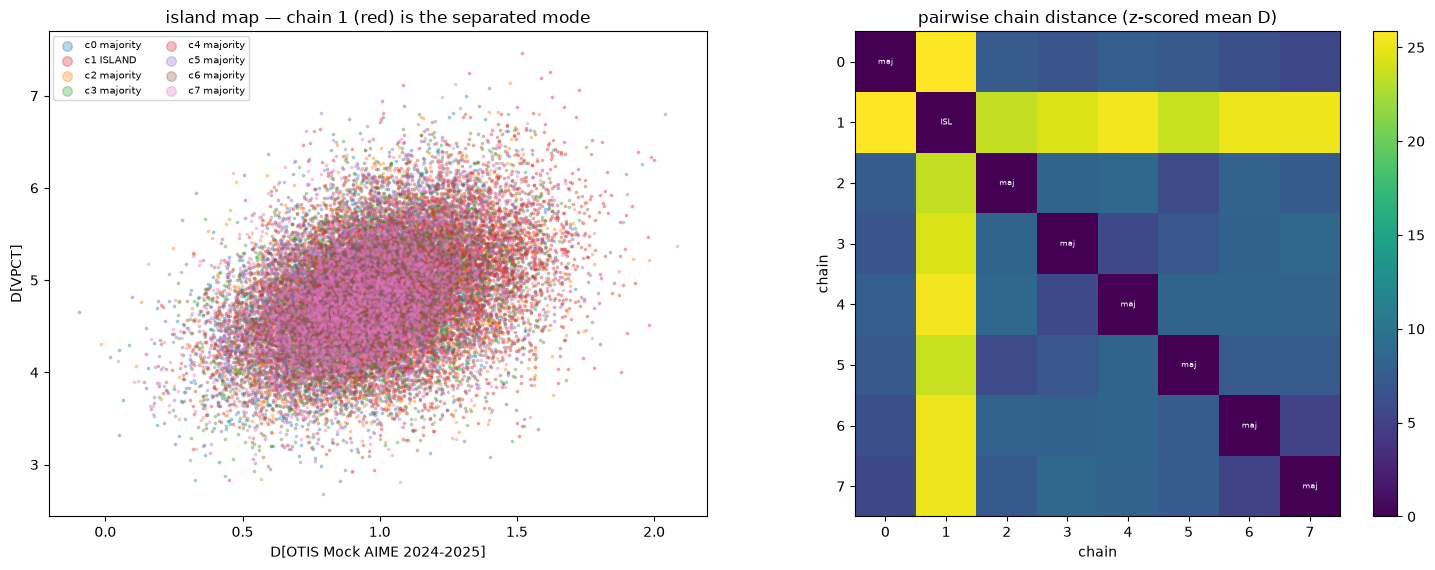

In [11]:
cm = idata.posterior["D"].mean("draw").values
spread = cm.max(0) - cm.min(0)
b1, b2 = np.argsort(spread)[::-1][:2]
fig, ax = plt.subplots(1, 2, figsize=(14.5, 5.8))
for c in range(NCH):
    d = idata.posterior["D"].values[c, :, [b1, b2]]
    ax[0].scatter(d[0], d[1], s=3, alpha=0.3,
                  color=("tab:red" if not same[c] else None), label=f"c{c} {labels[c]}")
ax[0].set(title="island map — chain 1 (red) is the separated mode",
          xlabel=f"D[{BENCH[b1][:26]}]", ylabel=f"D[{BENCH[b2][:26]}]")
ax[0].legend(ncol=2, fontsize=7, markerscale=4)
z = (cm - cm.mean(0)) / (cm.std(0) + 1e-9)
im = ax[1].imshow(squareform(pdist(z)), cmap="viridis")
ax[1].set(title="pairwise chain distance (z-scored mean D)", xlabel="chain", ylabel="chain")
for c in range(NCH):
    ax[1].text(c, c, labels[c][:3], ha="center", va="center", fontsize=6, color="w")
fig.colorbar(im, ax=ax[1], fraction=0.046)
fig.tight_layout(); plt.show()

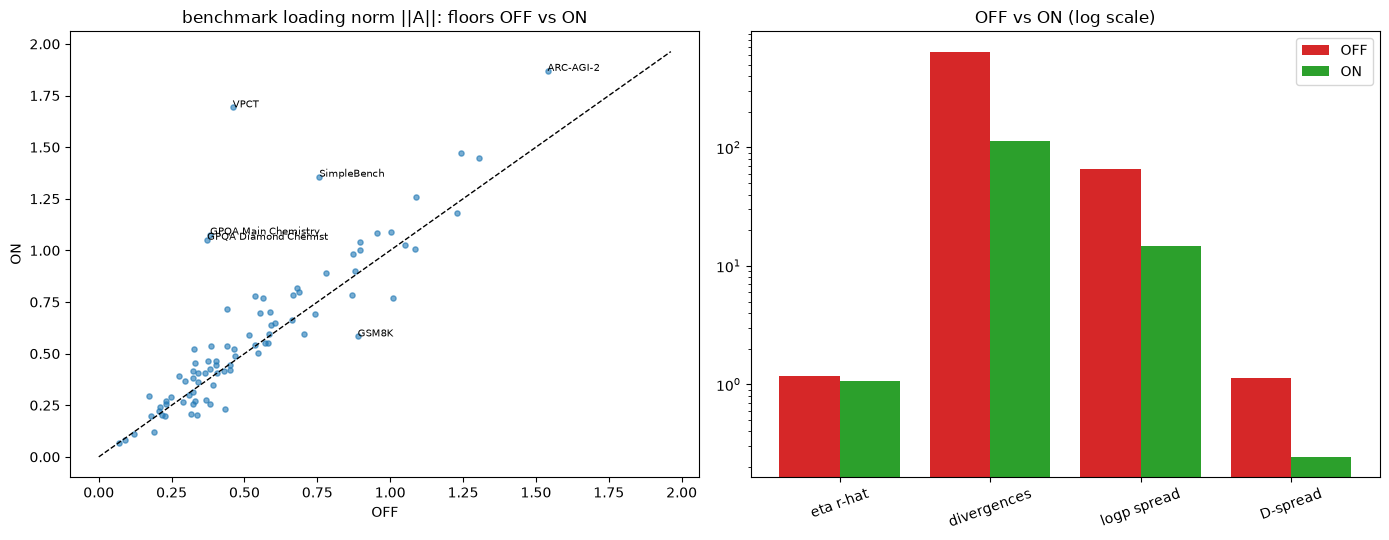

In [12]:
off = az.from_netcdf(OFF)
def rownorms(t):
    A = t.posterior["A"].mean(("chain", "draw")).values
    bench = list(t.posterior["bench"].values)
    return {b: float(np.linalg.norm(A[i])) for i, b in enumerate(bench)}
n_off, n_on = rownorms(off), rownorms(idata)

fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
xo = np.array([n_off[b] for b in BENCH]); xn = np.array([n_on[b] for b in BENCH])
ax[0].scatter(xo, xn, s=14, alpha=0.6)
lim = max(xo.max(), xn.max()) * 1.05
ax[0].plot([0, lim], [0, lim], "k--", lw=1)
for i in np.argsort(np.abs(xn - xo))[::-1][:6]:
    ax[0].annotate(BENCH[i][:20], (xo[i], xn[i]), fontsize=7)
ax[0].set(title="benchmark loading norm ||A||: floors OFF vs ON", xlabel="OFF", ylabel="ON")

METR = {"eta r-hat": (1.184, az.rhat(eta)["eta"].max().item()),
        "divergences": (int(off.sample_stats["diverging"].values.sum()), int(div.sum())),
        "logp spread": (65.8, float(logp.max() - logp.min())),
        "D-spread": (1.14, float(spread.max()))}
xlab = list(METR.keys()); vo = [METR[k][0] for k in xlab]; vn = [METR[k][1] for k in xlab]
xp = np.arange(len(xlab))
ax[1].bar(xp - 0.2, vo, 0.4, label="OFF", color="tab:red")
ax[1].bar(xp + 0.2, vn, 0.4, label="ON", color="tab:green")
ax[1].set(title="OFF vs ON (log scale)", yscale="log", xticks=xp, xticklabels=xlab)
ax[1].tick_params(axis="x", rotation=20); ax[1].legend()
fig.tight_layout(); plt.show()
del off

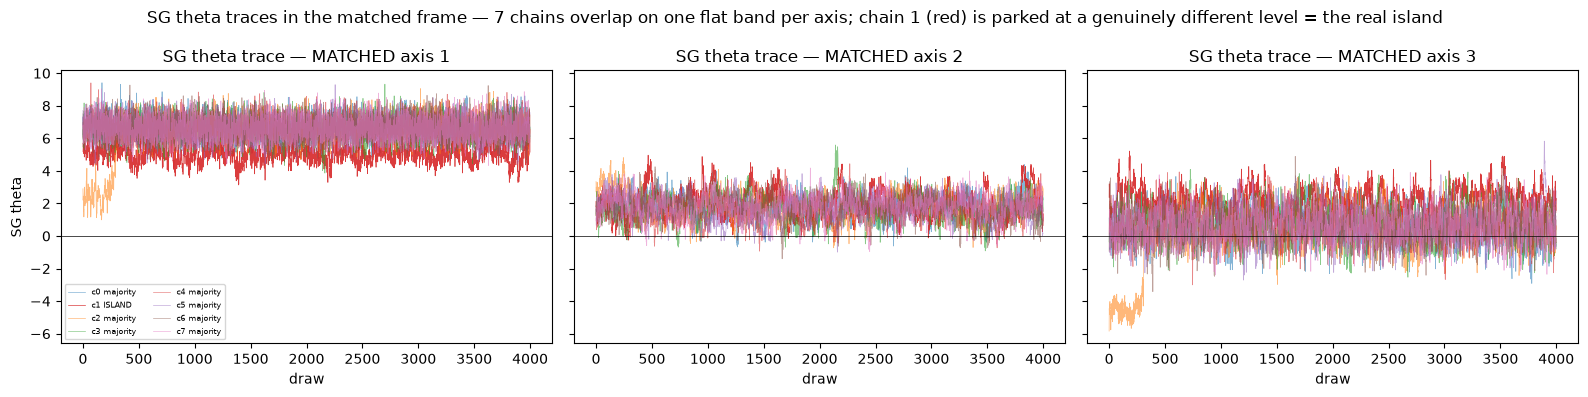

In [13]:
th_full = idata.posterior["theta"].values[:, :, SG, :]   # (chain, draw, K)
th_full_m = np.stack([np.column_stack(
    [MATCH[c][1][j] * th_full[c, :, MATCH[c][0][j]] for j in range(3)])
    for c in range(NCH)])                                # matched frame
fig, ax = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for k in range(3):
    for c in range(NCH):
        ax[k].plot(th_full_m[c, :, k], lw=0.5,
                   alpha=0.9 if not same[c] else 0.55,
                   color=("tab:red" if not same[c] else None),
                   label=f"c{c} {labels[c]}")
    ax[k].axhline(0, c="k", lw=0.5)
    ax[k].set(title=f"SG theta trace — MATCHED axis {k+1}", xlabel="draw")
ax[0].set_ylabel("SG theta"); ax[0].legend(ncol=2, fontsize=6)
fig.suptitle("SG theta traces in the matched frame — 7 chains overlap on one flat band per "
             "axis; chain 1 (red) is parked at a genuinely different level = the real island")
fig.tight_layout(); plt.show()

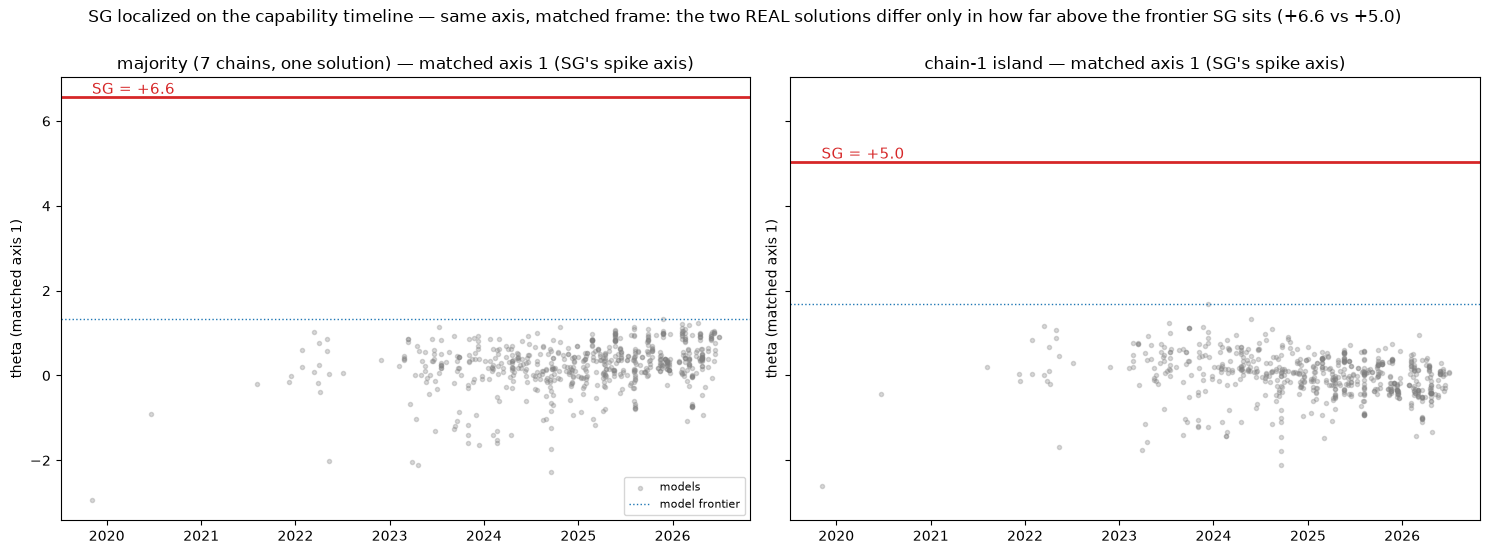

SG matched theta, majority: [6.6 1.7 0.6]
SG matched theta, island  : [5.  2.  2.2]


In [14]:
proc = pd.read_csv(ROOT / "data/processed/benchmarks_merged.csv")
date_map = (proc.dropna(subset=["release_date"]).drop_duplicates("model_version")
            .set_index("model_version")["release_date"])
models = list(data.mlookup.sort_values("model_idx")["model"])
dates = pd.to_datetime([date_map.get(m) for m in models], errors="coerce")
have = ~dates.isna() & ~data.is_human

def matched_theta(chains, axis):
    per_chain = [MATCH[c][1][axis]
                 * idata.posterior["theta"].isel(chain=c, latent=MATCH[c][0][axis]).mean("draw").values
                 for c in chains]
    return np.mean(per_chain, axis=0)

groups = [("majority (7 chains, one solution)", majority), ("chain-1 island", island)]
fig, ax = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)
for a, (title, ch) in zip(ax, groups):
    th1 = matched_theta(ch, 0)                     # matched axis 1 = SG's spike axis
    a.scatter(dates[have], th1[have], s=9, alpha=0.3, c="grey", label="models")
    a.axhline(th1[SG], color="tab:red", lw=2)
    a.annotate(f"SG = {th1[SG]:+.1f}", (dates[have].min(), th1[SG]),
               color="tab:red", fontsize=11, va="bottom")
    a.axhline(np.nanmax(th1[have]), color="tab:blue", ls=":", lw=1, label="model frontier")
    a.set(title=f"{title} — matched axis 1 (SG's spike axis)", ylabel="theta (matched axis 1)")
ax[0].legend(fontsize=8)
fig.suptitle("SG localized on the capability timeline — same axis, matched frame: the two REAL "
             "solutions differ only in how far above the frontier SG sits (+6.6 vs +5.0)", y=1.0)
fig.tight_layout(); plt.show()
print("SG matched theta, majority:", np.round([matched_theta(majority, j)[SG] for j in range(3)], 1))
print("SG matched theta, island  :", np.round([matched_theta(island, j)[SG] for j in range(3)], 1))

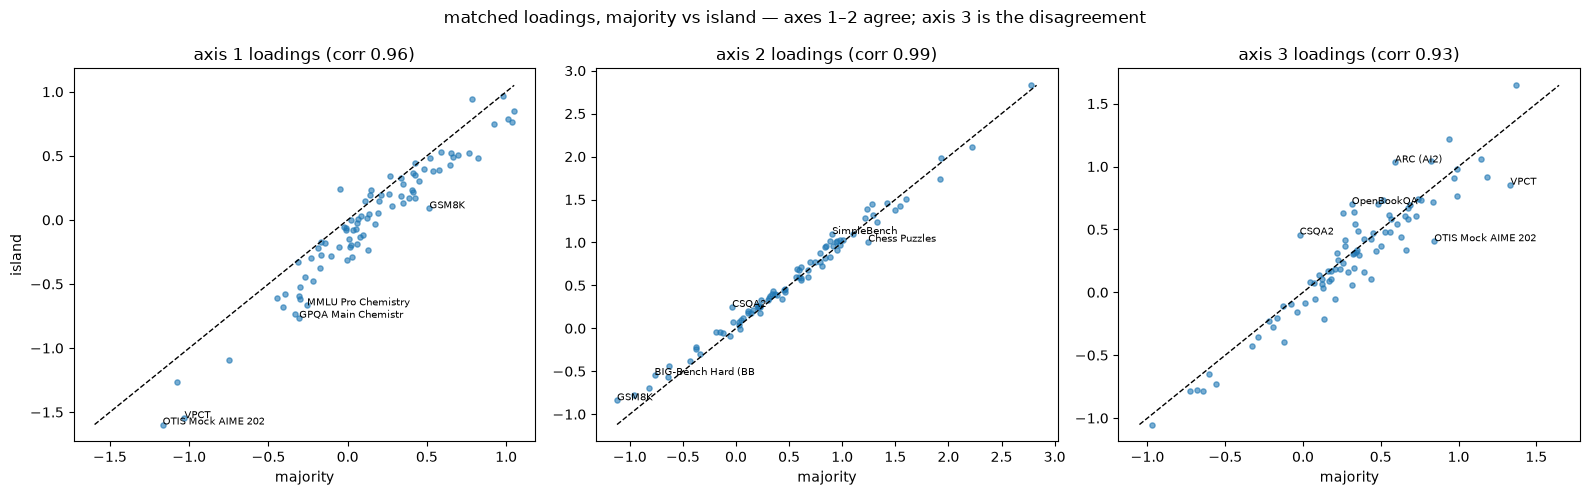

In [15]:
def matched_A(chains):
    per = []
    for c in chains:
        p, s, _ = MATCH[c]
        Ac = idata.posterior["A"].isel(chain=c).mean("draw").values
        per.append(np.column_stack([s[j] * Ac[:, p[j]] for j in range(3)]))
    return np.mean(per, axis=0)

A_maj, A_isl = matched_A(majority), matched_A(island)
fig, ax = plt.subplots(1, 3, figsize=(16, 5))
for j in range(3):
    r = np.corrcoef(A_maj[:, j], A_isl[:, j])[0, 1]
    ax[j].scatter(A_maj[:, j], A_isl[:, j], s=14, alpha=0.6)
    lim = [min(A_maj[:, j].min(), A_isl[:, j].min()), max(A_maj[:, j].max(), A_isl[:, j].max())]
    ax[j].plot(lim, lim, "k--", lw=1)
    for i in np.argsort(np.abs(A_isl[:, j] - A_maj[:, j]))[::-1][:5]:
        ax[j].annotate(BENCH[i][:18], (A_maj[i, j], A_isl[i, j]), fontsize=7)
    ax[j].set(title=f"axis {j+1} loadings (corr {r:.2f})",
              xlabel="majority", ylabel="island" if j == 0 else None)
fig.suptitle("matched loadings, majority vs island — axes 1–2 agree; axis 3 is the disagreement")
fig.tight_layout(); plt.show()

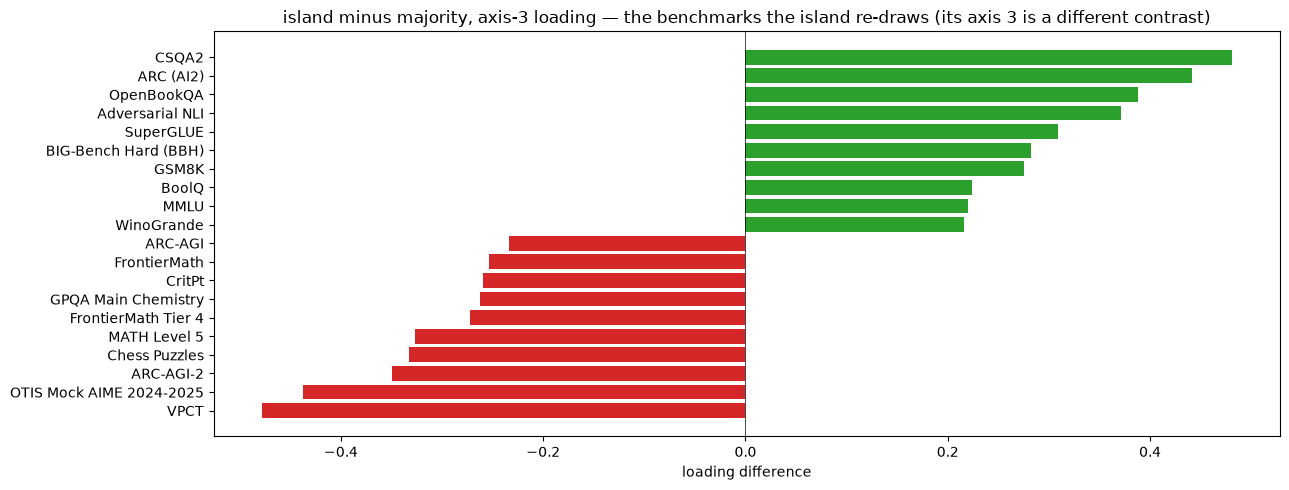

In [16]:
diff3 = A_isl[:, 2] - A_maj[:, 2]
order = np.argsort(diff3)
show = np.concatenate([order[:10], order[-10:]])
fig, ax = plt.subplots(figsize=(13, 5))
ax.barh([BENCH[i][:26] for i in show], diff3[show],
        color=["tab:red" if diff3[i] < 0 else "tab:green" for i in show])
ax.axvline(0, c="k", lw=0.5)
ax.set(title="island minus majority, axis-3 loading — the benchmarks the island re-draws "
       "(its axis 3 is a different contrast)", xlabel="loading difference")
fig.tight_layout(); plt.show()

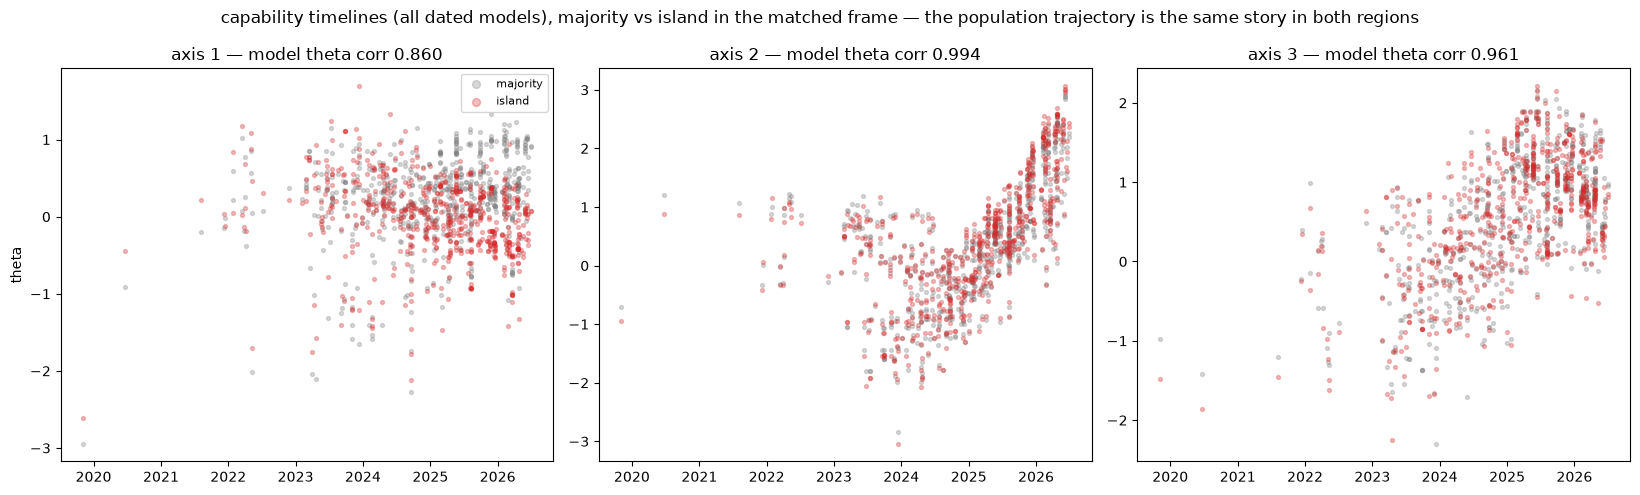

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(16.5, 5), sharex=True)
for j in range(3):
    tm, ti = matched_theta(majority, j), matched_theta(island, j)
    r = np.corrcoef(tm, ti)[0, 1]
    ax[j].scatter(dates[have], tm[have], s=8, alpha=0.3, c="grey", label="majority")
    ax[j].scatter(dates[have], ti[have], s=8, alpha=0.3, c="tab:red", label="island")
    ax[j].set(title=f"axis {j+1} — model theta corr {r:.3f}", ylabel="theta" if j == 0 else None)
ax[0].legend(fontsize=8, markerscale=2)
fig.suptitle("capability timelines (all dated models), majority vs island in the matched frame — "
             "the population trajectory is the same story in both regions")
fig.tight_layout(); plt.show()

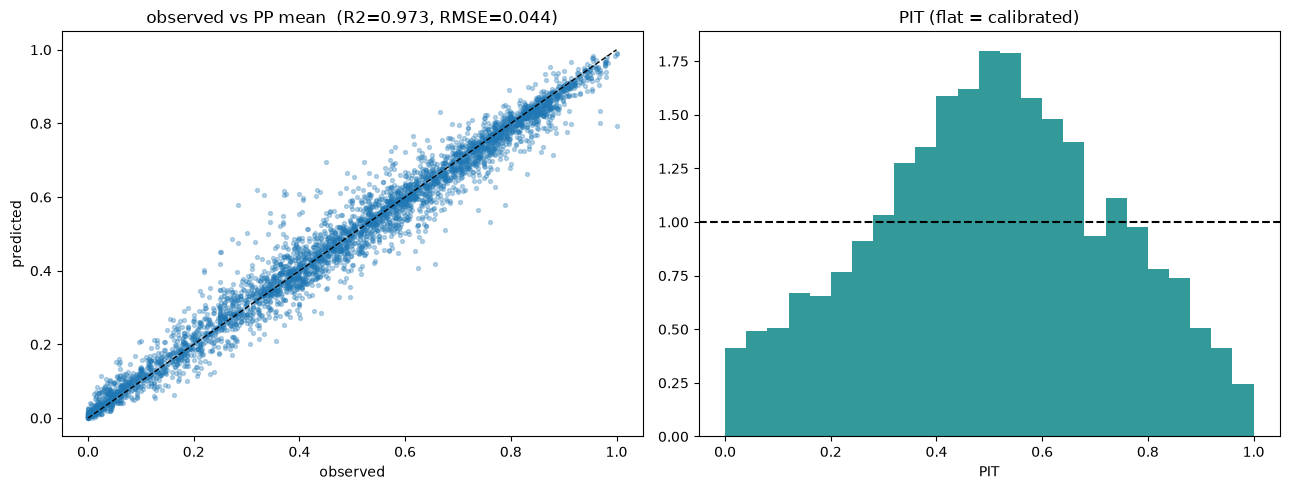

In [18]:
yrep = posterior_predictive_mirt(idata, clipped, floor_c=floors, max_draws=500)
gof = compute_gof(yrep, clipped)
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].scatter(clipped.scores, gof.y_pred_mean, s=8, alpha=0.3)
ax[0].plot([0, 1], [0, 1], "k--", lw=1)
ax[0].set(title=f"observed vs PP mean  (R2={gof.metrics['bayesian_r2']:.3f}, "
          f"RMSE={gof.metrics['rmse']:.3f})", xlabel="observed", ylabel="predicted")
ax[1].hist(gof.pit, bins=25, color="teal", alpha=0.8, density=True)
ax[1].axhline(1.0, ls="--", c="k")
ax[1].set(title="PIT (flat = calibrated)", xlabel="PIT")
fig.tight_layout(); plt.show()

# Residual human-block sub-mode (final 10k trace)

The fresh 8×10,000 floors fit (2026-07-17) shows the same signature as the
8×4,000 run above: **one chain sits ~15 nats below the rest, with the same
loading structure** (min matched loading corr 0.97, D-spread 0.24). Checks on
the 10k trace settled what it is:

- **Not warmup.** The deficit is flat across all 10,000 kept draws; discarding
  the first 2,000 or 5,000 draws leaves eta r-hat unchanged (1.031 → 1.030 →
  1.031); the chain's step size is normal. It is a *stationary* sub-mode,
  entered by ~1 chain in 8 in both independent runs.
- **It lives in the human tiers.** After sign/permutation matching, the
  sub-mode chain reapportions the *upper human tiers* between matched axes
  1 and 3 (the pair correlated at Φ ≈ 0.74). Machine models barely move:
  median matched-frame deviation 0.32, **none above 1.0** — the graphs below
  show the scale honestly, with 94% intervals, so the shift can be judged
  against the posterior spread rather than described in words.

Reading: floors merged the machine-side island structure completely; what
remains is one mirror-image apportionment of the sparsely-observed human
hierarchy (55 observations across 9 tiers) across two correlated axes,
~15 nats less likely than the main mode.

In [ ]:
# the two modes: majority (7 chains pooled) vs sub-mode (chain 0), matched frame
TEN = (ROOT / "results/mirt_signed_humanprior_lineageprior_floors"
       / "trace_mirt_k3_signed_humanprior_lineageprior_floors.nc")
i10 = az.from_netcdf(TEN)
n_ch = i10.posterior.sizes["chain"]
lp10 = i10.sample_stats["logp"].mean("draw").values
sub_chain, ref_chain = int(np.argmin(lp10)), int(np.argmax(lp10))

A10 = i10.posterior["A"].mean("draw").values                # (chain, B, K)

def match10(c, K=3):
    used, perm, sign = set(), [0] * K, [1.0] * K
    for ja in range(K):
        best = (-1.0, None, 1.0)
        for jb in range(K):
            if jb in used:
                continue
            r = np.corrcoef(A10[ref_chain][:, ja], A10[c][:, jb])[0, 1]
            if abs(r) > best[0]:
                best = (abs(r), jb, np.sign(r))
        used.add(best[1])
        perm[ja], sign[ja] = best[1], best[2]
    return perm, sign

M10 = [match10(c) for c in range(n_ch)]

models10 = list(data.mlookup.sort_values("model_idx")["model"])
TIERS = ["Average Human", "High School Qualifier", "Skilled Generalist",
         "Committee of Average Humans", "Committee of Skilled Generalists",
         "High School Top Performer", "Domain Expert", "Top Performer",
         "Committee of Domain Experts"]
t_idx = [models10.index(t) for t in TIERS]
th_h = i10.posterior["theta"].isel(model=t_idx).values      # (chain, draw, 9, K)
th_hm = np.stack([np.stack([M10[c][1][j] * th_h[c, :, :, M10[c][0][j]]
                            for j in range(3)], axis=-1)
                  for c in range(n_ch)])                    # matched frame
rest = [c for c in range(n_ch) if c != sub_chain]
maj = th_hm[rest].reshape(-1, len(TIERS), 3)                # pooled majority draws
sub = th_hm[sub_chain]

fig, axs = plt.subplots(1, 3, figsize=(15, 5.5), sharey=True)
y = np.arange(len(TIERS))
for k in range(3):
    a = axs[k]
    for vals, off, col, lbl in [(maj[:, :, k], 0.14, "tab:blue", "majority mode (7 chains)"),
                                (sub[:, :, k], -0.14, "tab:red", "sub-mode (chain 0)")]:
        m = vals.mean(axis=0)
        lo, hi = np.quantile(vals, 0.025, axis=0), np.quantile(vals, 0.975, axis=0)
        a.errorbar(m, y + off, xerr=[m - lo, hi - m], fmt="o", ms=5, lw=1.6,
                   color=col, label=lbl if k == 0 else None)
    a.set_yticks(y)
    a.set_yticklabels(TIERS, fontsize=9)
    a.axvline(0, c="k", lw=0.5)
    AXT = ["Axis 1 — reasoning & math", "Axis 2 — agentic & coding",
       "Axis 3 — knowledge & commonsense"]
    a.set(title=AXT[k], xlabel="theta (mean, 95% interval)")
axs[0].legend(fontsize=9, loc="lower right")
fig.suptitle("Human tiers: majority mode vs sub-mode (matched frame)")
fig.tight_layout()
fig.savefig(ROOT / "plots/mirt/human_submode_tiers.png", dpi=130)
fig.savefig(ROOT / "plots/mirt/human_submode_tiers.pdf")
plt.show()

In [ ]:
# scale check against the rest of the model: full-posterior overlap for the
# most-shifted tiers, and the machine-model deviation distribution next to the
# human ones — the anti-exaggeration panel
rest = [c for c in range(n_ch) if c != sub_chain]
shift = np.abs(mean_h[sub_chain] - mean_h[rest].mean(axis=0)).max(axis=1)
top_t = np.argsort(shift)[::-1][:4]

fig, axs = plt.subplots(2, 4, figsize=(16, 6.2), sharex="col")
for col, ti in enumerate(top_t):
    for row, k in enumerate([0, 2]):                       # the affected axis pair
        a = axs[row, col]
        a.hist(th_hm[rest][:, :, ti, k].ravel(), bins=60, density=True,
               alpha=0.55, color="grey", label="other 7 chains")
        a.hist(th_hm[sub_chain, :, ti, k], bins=60, density=True,
               alpha=0.6, color="tab:red", label="sub-mode chain")
        if row == 0:
            a.set_title(TIERS[ti], fontsize=9)
        a.set_ylabel(f"matched axis {k + 1}" if col == 0 else None)
axs[0, 0].legend(fontsize=7)
fig.suptitle("Full posterior overlap, sub-mode chain vs the rest — the four most-shifted tiers "
             "on the affected axis pair")
fig.tight_layout()
fig.savefig(ROOT / "plots/mirt/human_submode_densities.png", dpi=130)
fig.savefig(ROOT / "plots/mirt/human_submode_densities.pdf")
plt.show()

# machine models in the same matched frame: does the sub-mode move anything else?
thm10 = i10.posterior["theta"].mean("draw").values          # (chain, M, K)
Tm10 = np.stack([np.column_stack([M10[c][1][j] * thm10[c][:, M10[c][0][j]]
                                  for j in range(3)]) for c in range(n_ch)])
dev10 = np.abs(Tm10[sub_chain] - Tm10[rest].mean(axis=0)).max(axis=1)
is_h = np.array([m in set(TIERS) for m in models10])

fig, a = plt.subplots(figsize=(11, 4))
a.hist(dev10[~is_h], bins=50, color="tab:blue", alpha=0.75,
       label=f"{(~is_h).sum()} machine models "
             f"(median {np.median(dev10[~is_h]):.2f}, max {dev10[~is_h].max():.2f})")
for i in np.where(is_h)[0]:
    a.axvline(dev10[i], color="tab:red", lw=1.2)
    a.annotate(models10[i][:22], (dev10[i], a.get_ylim()[1] * 0.55),
               rotation=90, fontsize=6.5, color="tab:red", va="top")
a.set(title="max |sub-mode − rest| per test-taker (matched frame): the sub-mode is a "
            "human-tier phenomenon; machine abilities are essentially untouched",
      xlabel="matched-frame deviation", ylabel="models")
a.legend(fontsize=8)
fig.tight_layout()
fig.savefig(ROOT / "plots/mirt/human_submode_machine_scale.png", dpi=130)
fig.savefig(ROOT / "plots/mirt/human_submode_machine_scale.pdf")
plt.show()